In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import kagglehub
from kagglehub import KaggleDatasetAdapter

C:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
data = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"johnsmith88/heart-disease-dataset", "heart.csv")
data

100%|█████████████████████████████████████████████████████████████████████████████| 37.2k/37.2k [00:01<00:00, 21.2kB/s]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
df = pd.DataFrame(data)
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
def describe(df):

    variables = []
    count = []
    unique = []
    missing_values = []
    duplicated = []

    for col in df.columns:
        variables.append(col)
        count.append(df[col].count())
        unique.append(len(df[col].unique()))
        missing_values.append(df[col].isna().sum())
        duplicated.append(df.duplicated().sum())

    result = pd.DataFrame({
        'variables' : variables,
        'count' : count,
        'unique' : unique,
        'missing_values' : missing_values,
        'duplicated' : duplicated
    })

    return result
    
describe(df)

,variables,count,unique,missing_values,duplicated
0,age,1025,41,0,723
1,sex,1025,2,0,723
2,cp,1025,4,0,723
3,trestbps,1025,49,0,723
4,chol,1025,152,0,723
5,fbs,1025,2,0,723
6,restecg,1025,3,0,723
7,thalach,1025,91,0,723
8,exang,1025,2,0,723
9,oldpeak,1025,40,0,723


In [11]:
df_cleand = df.drop_duplicates()
describe(df_cleand)

,variables,count,unique,missing_values,duplicated
0,age,302,41,0,0
1,sex,302,2,0,0
2,cp,302,4,0,0
3,trestbps,302,49,0,0
4,chol,302,152,0,0
5,fbs,302,2,0,0
6,restecg,302,3,0,0
7,thalach,302,91,0,0
8,exang,302,2,0,0
9,oldpeak,302,40,0,0


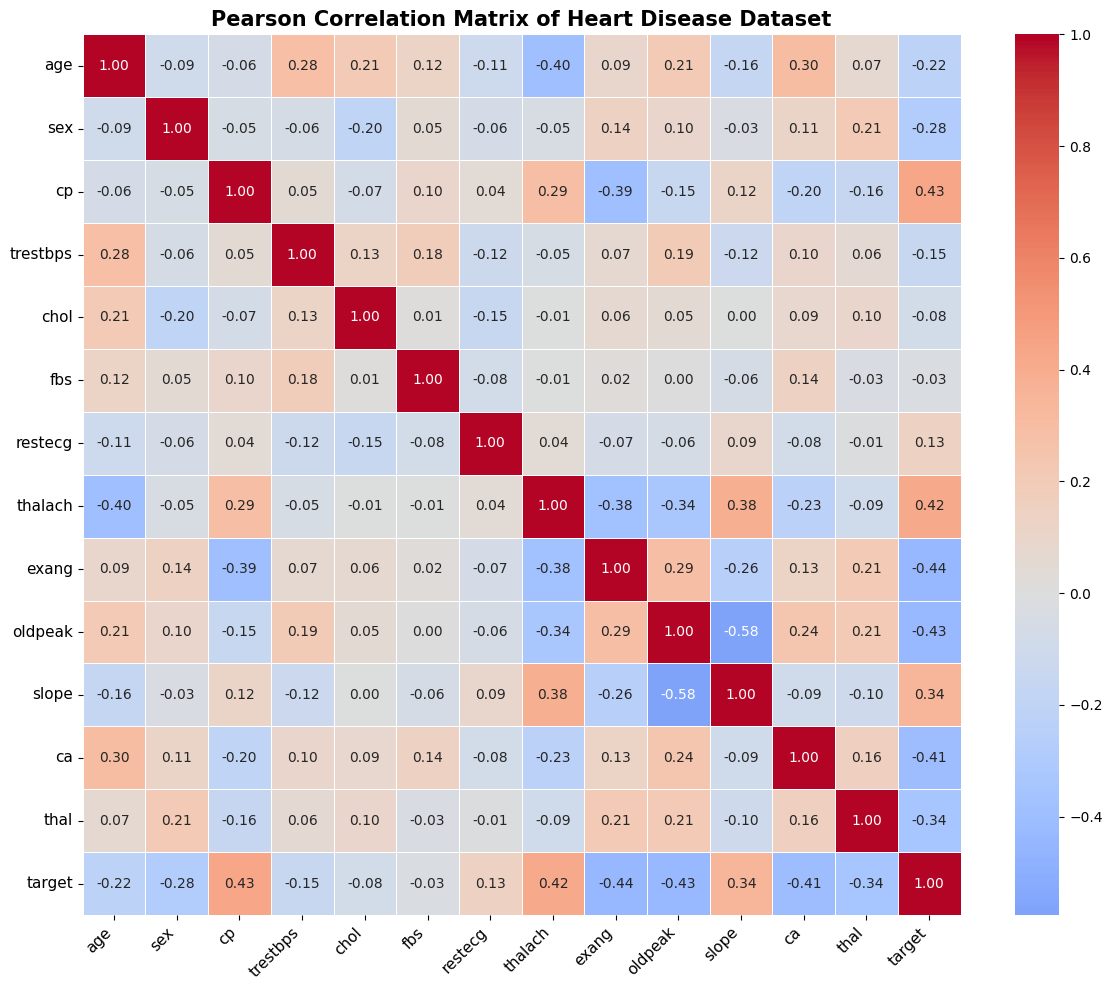

In [13]:
import seaborn as sns

corr_matrix = df_cleand.corr()

# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
     ax=ax
)

ax.set_title('Pearson Correlation Matrix of Heart Disease Dataset', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Count of Patients (Target = 1)')

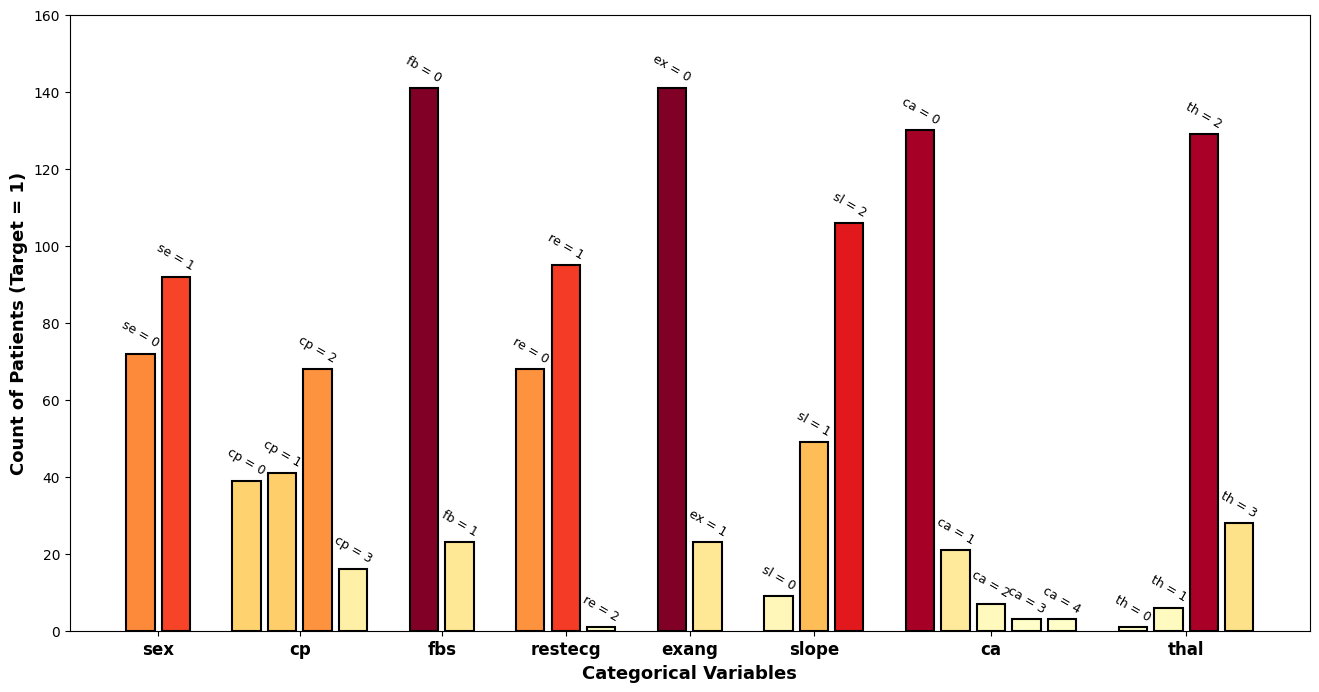

In [14]:
# Filter to patients with heart disease (target = 1)
df_targeted = df_cleand[df_cleand['target'] == 1]

# List of categorical variables to visualize
variables = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# Initialize the figure for the grouped bar plot
fig, ax = plt.subplots(figsize=(16, 8))

# Calculate the global min/max counts for consistent color scaling
all_values = []
for var in variables:
    counts = df_targeted[var].value_counts().sort_index()
    all_values.extend(counts.values)

min_val = min(all_values)
max_val = max(all_values)

cmap = plt.cm.YlOrRd

current_position = 0
group_positions = []
group_labels = []
xtick_positions = []
# Iterate through each variable to create its bar chart group
for var in variables:
    counts = df_targeted[var].value_counts().sort_index()
    num_bars = len(counts)

    positions = np.arange(current_position, current_position + num_bars)

    # Normalize counts to map them to the colormap
    normalized_values = (counts.values - min_val) / (max_val - min_val)
    bar_colors = [cmap(val) for val in normalized_values]

    # Create the bars for the current variable
    bars = ax.bar(positions, counts.values, width=0.8,
                   color=bar_colors, edgecolor='black', linewidth=1.5)
# Annotate each bar with its category value (e.g., 'cp = 0')
    for i, (bar, value, index) in enumerate(zip(bars, counts.values, counts.index)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{var[0:2]} = {index}', ha='center', va='bottom', fontsize=9, rotation=-30)

    group_center = current_position + (num_bars - 1) / 2
    xtick_positions.append(group_center)

    current_position += num_bars + 1

# Configure plot and labels
ax.set_ylim(0, 160)
ax.set_xticks(xtick_positions)
ax.set_xticklabels(variables, fontsize=12, fontweight='bold')
ax.set_xlabel('Categorical Variables', fontsize=13, fontweight='bold')
ax.set_ylabel('Count of Patients (Target = 1)', fontsize=13, fontweight='bold')



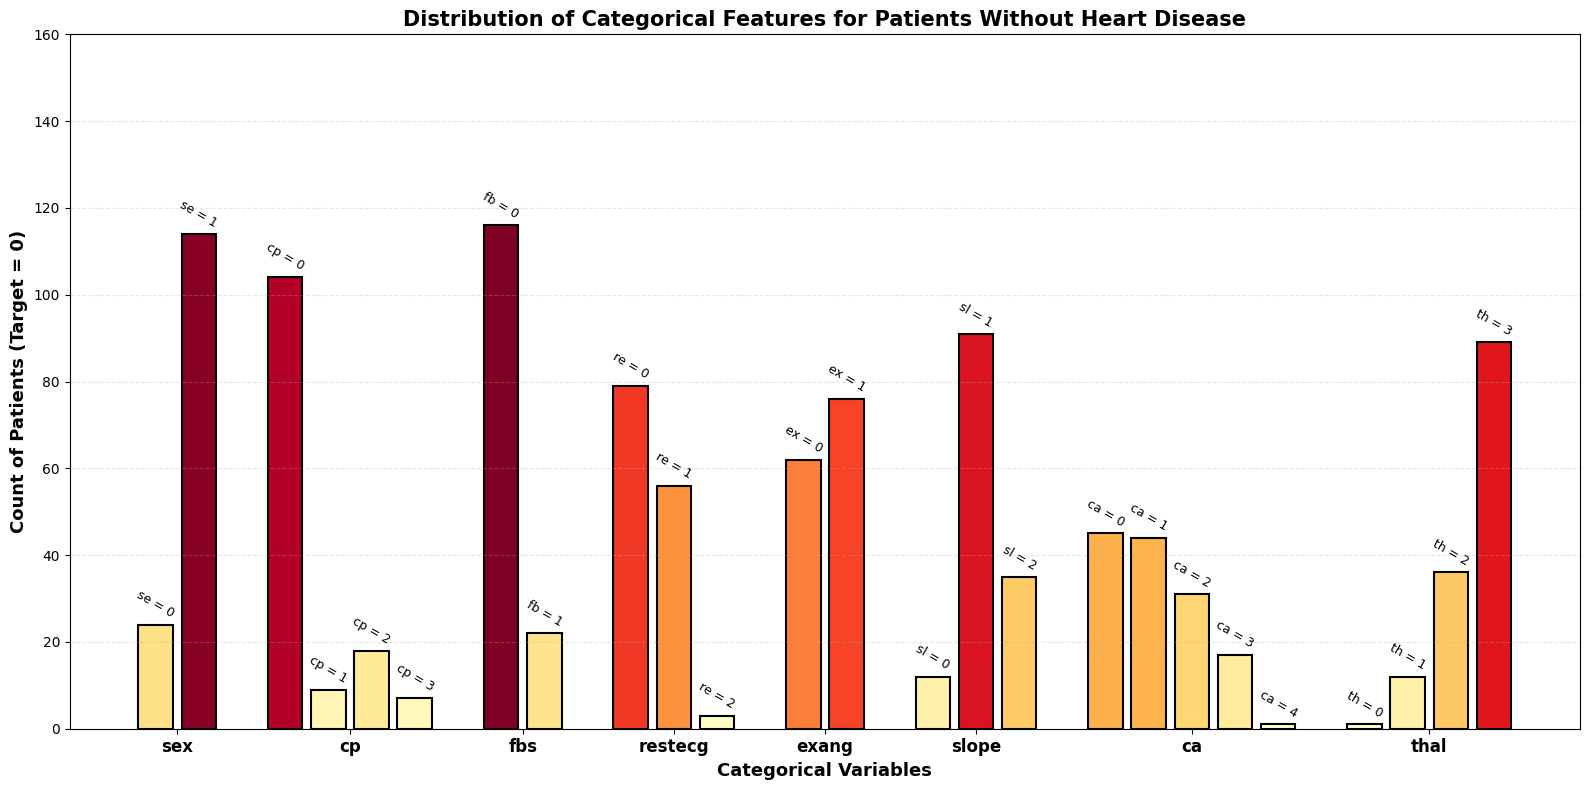

In [15]:
# Filter to patients without heart disease (target = 0)
df_targeted = df_cleand[df_cleand['target'] == 0]

# List of categorical variables to visualize
variables = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# Initialize the figure for the grouped bar plot
fig, ax = plt.subplots(figsize=(16, 8))

# Calculate the global min/max counts for consistent color scaling
all_values = []
for var in variables:
    counts = df_targeted[var].value_counts().sort_index()
    all_values.extend(counts.values)

min_val = min(all_values)
max_val = max(all_values)

cmap = plt.cm.YlOrRd

current_position = 0
group_positions = []
group_labels = []
xtick_positions = []

# Iterate through each variable to create its bar chart group
for var in variables:
    counts = df_targeted[var].value_counts().sort_index()
    num_bars = len(counts)
    
    positions = np.arange(current_position, current_position + num_bars)

    # Normalize counts to map them to the colormap
    normalized_values = (counts.values - min_val) / (max_val - min_val)
    bar_colors = [cmap(val) for val in normalized_values]

    # Create the bars for the current variable
    bars = ax.bar(positions, counts.values, width=0.8,
                   color=bar_colors, edgecolor='black', linewidth=1.5)

    # Annotate each bar with its category value
    for i, (bar, value, index) in enumerate(zip(bars, counts.values, counts.index)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{var[0:2]} = {index}', ha='center', va='bottom', fontsize=9, rotation=-30)

    group_center = current_position + (num_bars - 1) / 2
    xtick_positions.append(group_center)

    current_position += num_bars + 1

# Configure plot and labels
ax.set_ylim(0, 160)
ax.set_xticks(xtick_positions)
ax.set_xticklabels(variables, fontsize=12, fontweight='bold')
ax.set_xlabel('Categorical Variables', fontsize=13, fontweight='bold')
ax.set_ylabel('Count of Patients (Target = 0)', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Categorical Features for Patients Without Heart Disease', fontsize=15, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

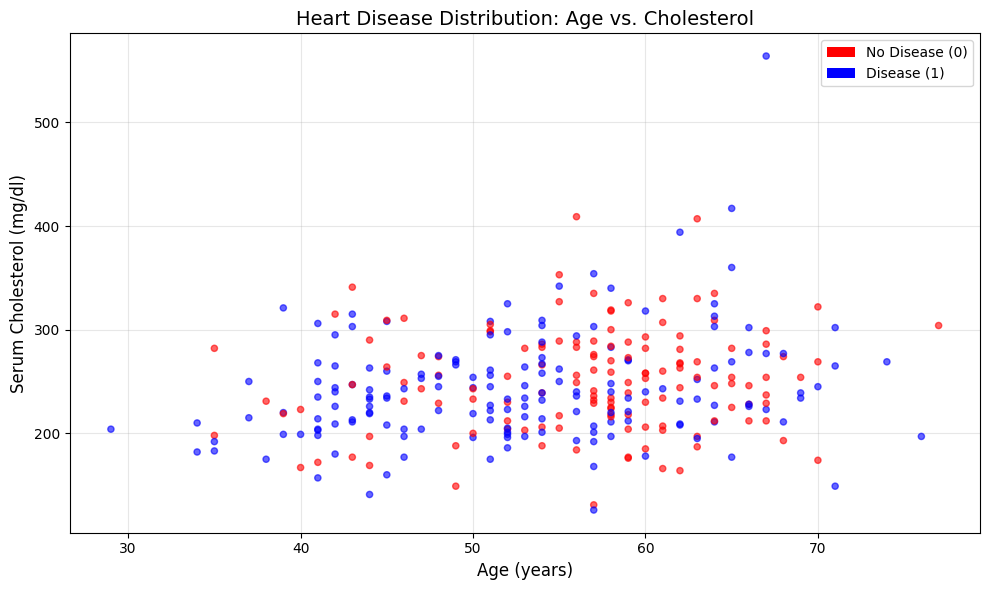

In [16]:
# Extract feature columns for visualization
x = df_cleand['age']
y = df_cleand['chol']
disease_status = df_cleand['target']

# Red for No Disease (0), Blue for Disease (1)
colors = []
for p in disease_status:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

fig, (ax) = plt.subplots(figsize=(10, 6))
# Scatter plot of all patients
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Serum Cholesterol (mg/dl)', fontsize=12)
ax.set_title('Heart Disease Distribution: Age vs. Cholesterol', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for disease classification
legend_elements = [Patch(facecolor='red', label='No Disease (0)'),
                   Patch(facecolor='blue', label='Disease (1)')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

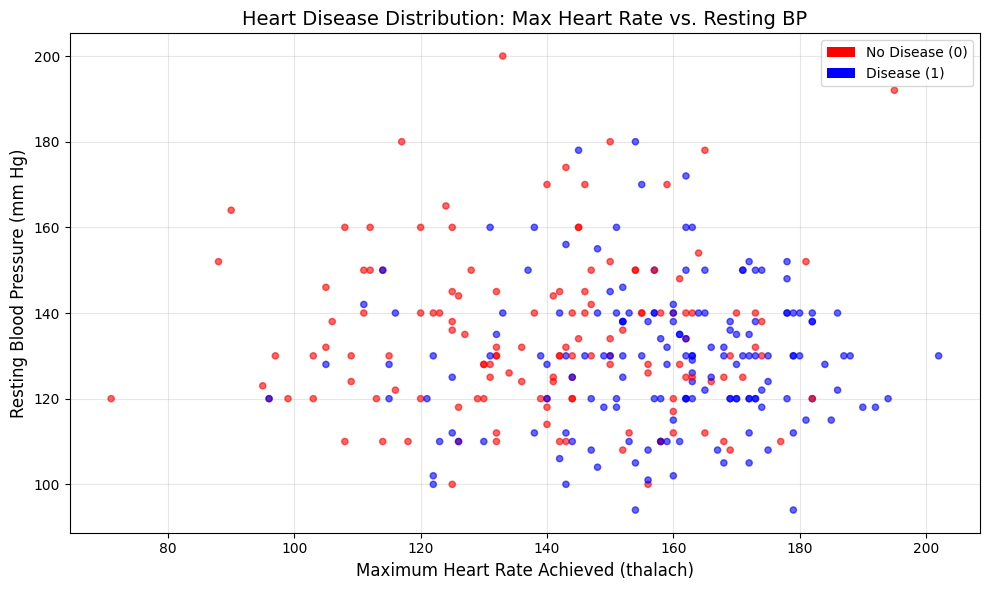

In [17]:
# Extract feature columns for visualization
x = df_cleand['thalach']
y = df_cleand['trestbps']
disease_status = df_cleand['target']

# Red for No Disease (0), Blue for Disease (1)
colors = []
for p in disease_status:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

fig, (ax) = plt.subplots(figsize=(10, 6))

# Scatter plot of all patients
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

ax.set_xlabel('Maximum Heart Rate Achieved (thalach)', fontsize=12)
ax.set_ylabel('Resting Blood Pressure (mm Hg)', fontsize=12)
ax.set_title('Heart Disease Distribution: Max Heart Rate vs. Resting BP', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for disease classification
legend_elements = [Patch(facecolor='red', label='No Disease (0)'),
                   Patch(facecolor='blue', label='Disease (1)')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()


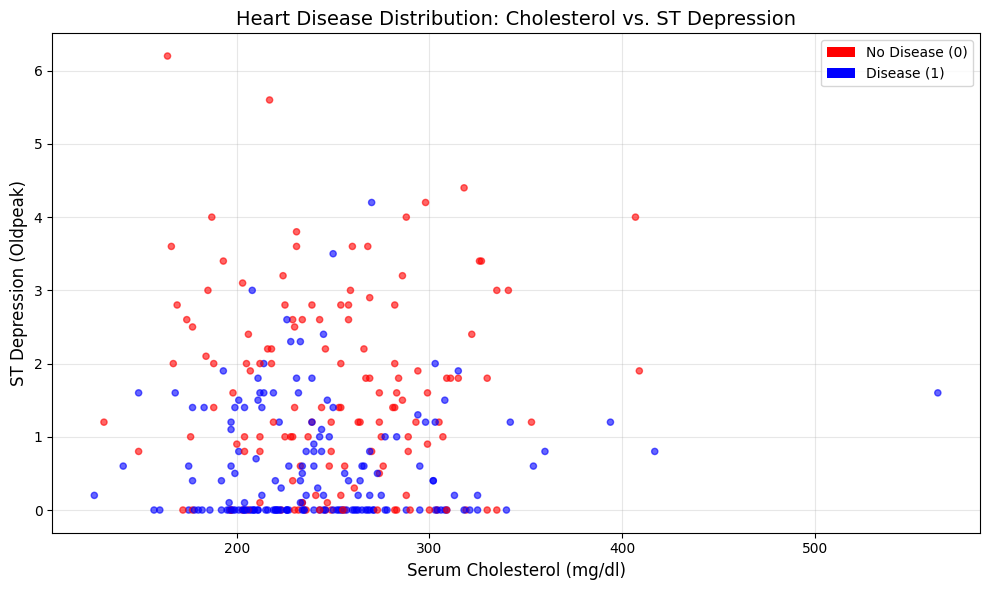

In [18]:
# Extract feature columns for visualization
x = df_cleand['chol']
y = df_cleand['oldpeak']
disease_status = df_cleand['target']

# Red for No Disease (0), Blue for Disease (1)
colors = []
for p in disease_status:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

fig, (ax) = plt.subplots(figsize=(10, 6))

# Scatter plot of all patients
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

ax.set_xlabel('Serum Cholesterol (mg/dl)', fontsize=12)
ax.set_ylabel('ST Depression (Oldpeak)', fontsize=12)
ax.set_title('Heart Disease Distribution: Cholesterol vs. ST Depression', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for disease classification
legend_elements = [Patch(facecolor='red', label='No Disease (0)'),
                   Patch(facecolor='blue', label='Disease (1)')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()